# Exploratory Data Analysis (EDA)

We load the cleaned dataset produced by `01_Data_Ingestion_Cleaning` and explore its structure, distributions, text characteristics and potential quality issues before moving to feature engineering and modeling.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Loading the cleaned dataset produced by 01_Data_Ingestion_Cleaning
df = pd.read_csv("data/reviews_cleaned.csv")
print(f"Loaded {len(df):,} reviews")
df.head()

Loaded 318,435 reviews


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,product_title,brand,description_clean,product_avg_rating,product_rating_count,price,store
0,4,12 mg is 12 on the periodic table people! Mg f...,This review is more to clarify someone else s ...,NaN,B07TDSJZMR,B07TDSJZMR,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2020-02-06 00:49:35.902,3,True,High Potency Magnesium Citrate Capsules 1000mg...,Life Nutrition,NaN,4.5,470,NaN,Life Nutrition
1,5,Fantastic,I have been suffering a couple months with hee...,NaN,B07KJVGNN5,B07KJVGNN5,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,2019-07-24 11:13:58.905,0,True,"Dr. Foot's Gel Heel Protectors, Plantar Fascii...",NaN,NaN,3.6,78,NaN,Dr.Foot
2,4,It holds the water and makes bubbles. That's w...,It's cheap and it does what I wanted. The mass...,NaN,B007HY7GC2,B092RP73CX,AEZGPLOYTSAPR3DHZKKXEFPAXUAA,2022-09-04 02:29:02.725,7,True,"Homedics Bubble Bliss Deluxe-Foot Spa, Heat Ma...",Homedics,NaN,4.4,8312,NaN,Homedics
3,1,Not for me,Didn't do a thing for me. Not saying they don'...,NaN,B08KYJLF5T,B08KYJLF5T,AEQAYV7RXZEBXMQIQPL6KCT2CFWQ,2022-01-20 23:53:07.262,0,True,Brain Supplement 1053mg - Premium Nootropic Br...,Nature's Nutrition,NaN,4.1,94,NaN,Nature's Nutrition
4,5,returned,it was a nice tray smaller than i expected but...,NaN,B01H0SVP9O,B01H0SVP9O,AHGAOIZVODNHYMNCBV4DECZH42UQ,2020-11-11 14:54:54.192,0,True,North American Walker Tray with Non-Slip Grip Mat,NaN,Walker tray with grip mat. Turn any walker int...,4.0,2072,26.9,North American Health + Wellness


## Corpus-Level Profiling

Basic shape, column types, missing values and sample size of the final merged dataset.

In [3]:
# Corpus size and column overview
print(f"Total reviews: {len(df):,}")
print(f"Unique products (parent_asin): {df['parent_asin'].nunique():,}")
print(f"Unique reviewers (user_id): {df['user_id'].nunique():,}")
print(f"Columns: {list(df.columns)}\n")

# Adding text length columns for analysis
df["char_len"] = df["text"].astype(str).str.len()
df["tok_len"]  = df["text"].astype(str).str.split().str.len()

print(df[["char_len", "tok_len"]].describe())

Total reviews: 318,435
Unique products (parent_asin): 6,971
Unique reviewers (user_id): 306,736
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'product_title', 'brand', 'description_clean', 'product_avg_rating', 'product_rating_count', 'price', 'store']

            char_len        tok_len
count  318435.000000  318435.000000
mean      165.522841      31.641098
std       224.249129      42.755804
min         1.000000       1.000000
25%        43.000000       8.000000
50%       100.000000      19.000000
75%       206.000000      40.000000
max     16337.000000    2797.000000


## Rating & Text Length Distributions

We check how ratings are distributed and how long reviews are in characters and tokens.

/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/3572521274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, ax=axes[0], palette="viridis")
/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/3572521274.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rating", y="tok_len", data=df, ax=axes[2], palette="viridis")


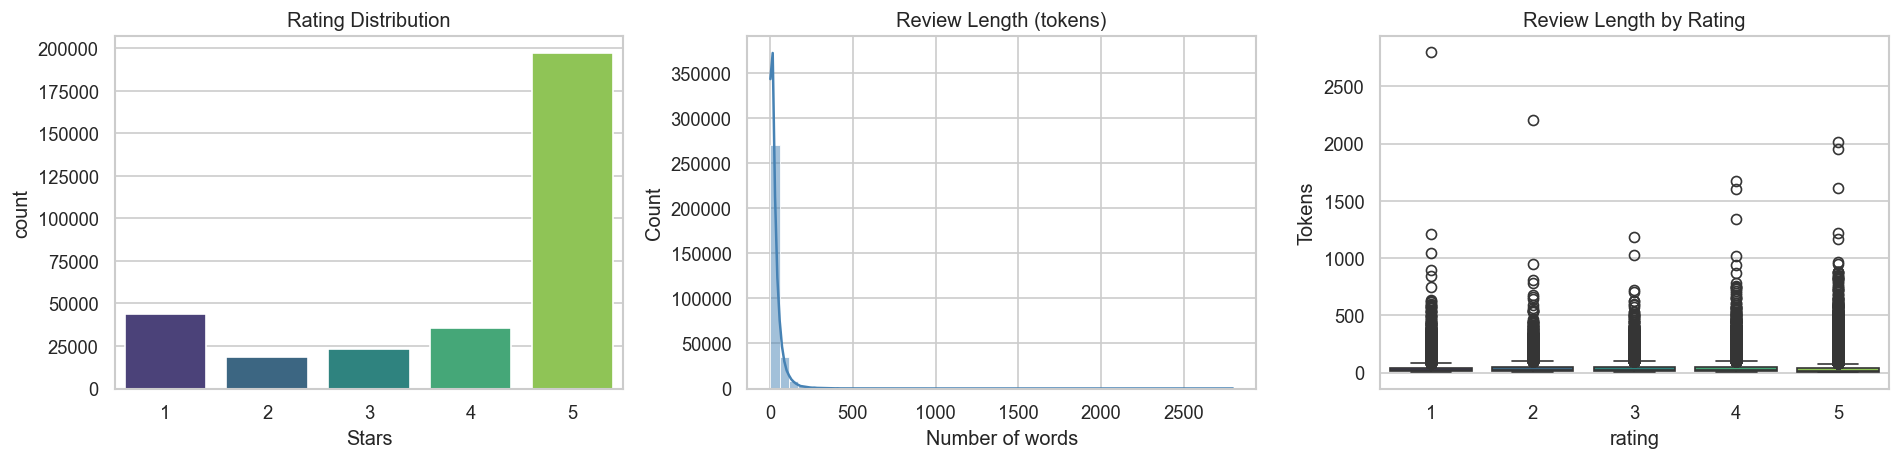

In [4]:
# Rating distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="rating", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Stars")

# Review length in tokens
sns.histplot(df["tok_len"], bins=50, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Review Length (tokens)")
axes[1].set_xlabel("Number of words")

# Review length by rating (boxplot)
sns.boxplot(x="rating", y="tok_len", data=df, ax=axes[2], palette="viridis")
axes[2].set_title("Review Length by Rating")
axes[2].set_ylabel("Tokens")

plt.tight_layout()
plt.show()

## Top Words and N-grams

Most frequent unigrams and bigrams in the corpus, after removing English stopwords.

/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/198079975.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=uni_freq, y=uni_terms, ax=axes[0], palette="crest")
/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/198079975.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bi_freq, y=bi_terms, ax=axes[1], palette="flare")


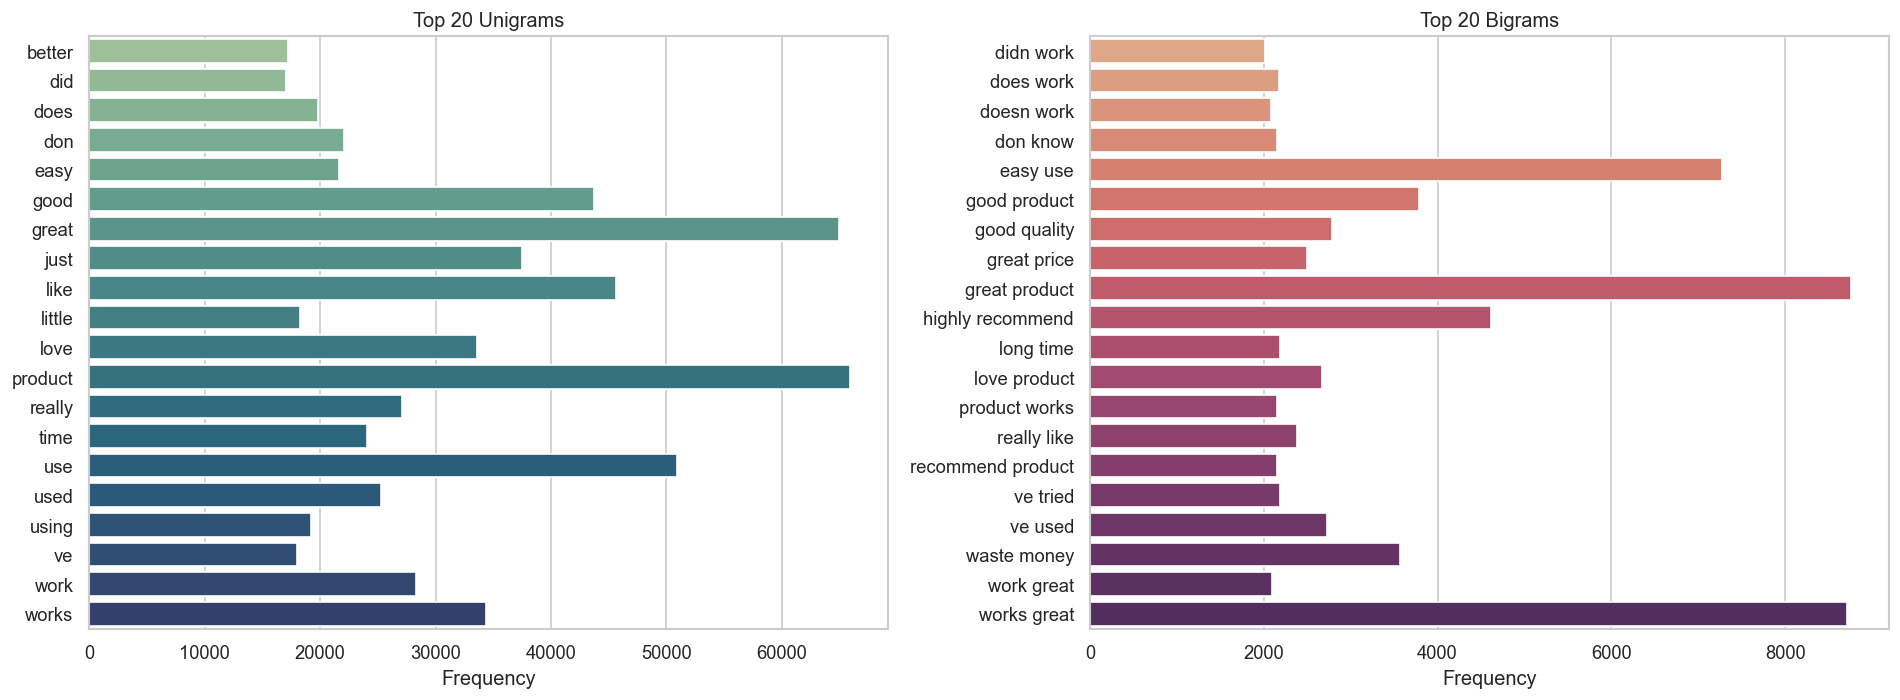

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

# Filling NaN texts with empty string to avoid vectorizer errors
texts = df["text"].fillna("").astype(str)

# Top 20 unigrams (no stopwords)
vec_uni = CountVectorizer(stop_words="english", max_features=20)
X_uni = vec_uni.fit_transform(texts)
uni_freq = X_uni.sum(axis=0).A1
uni_terms = vec_uni.get_feature_names_out()

# Top 20 bigrams (no stopwords)
vec_bi = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=20)
X_bi = vec_bi.fit_transform(texts)
bi_freq = X_bi.sum(axis=0).A1
bi_terms = vec_bi.get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=uni_freq, y=uni_terms, ax=axes[0], palette="crest")
axes[0].set_title("Top 20 Unigrams")
axes[0].set_xlabel("Frequency")

sns.barplot(x=bi_freq, y=bi_terms, ax=axes[1], palette="flare")
axes[1].set_title("Top 20 Bigrams")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

## TF-IDF Top Terms per Rating Class

We split reviews into positive (4-5 stars) and negative (1-2 stars) and extract the most distinctive terms for each group using TF-IDF.

/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/3201894937.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="tfidf_weight", y="term", data=top_pos, ax=axes[0], palette="Greens_r")
/var/folders/sv/yjdq88fd32x9j84rcbqcqql40000gn/T/ipykernel_22784/3201894937.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="tfidf_weight", y="term", data=top_neg, ax=axes[1], palette="Reds_r")


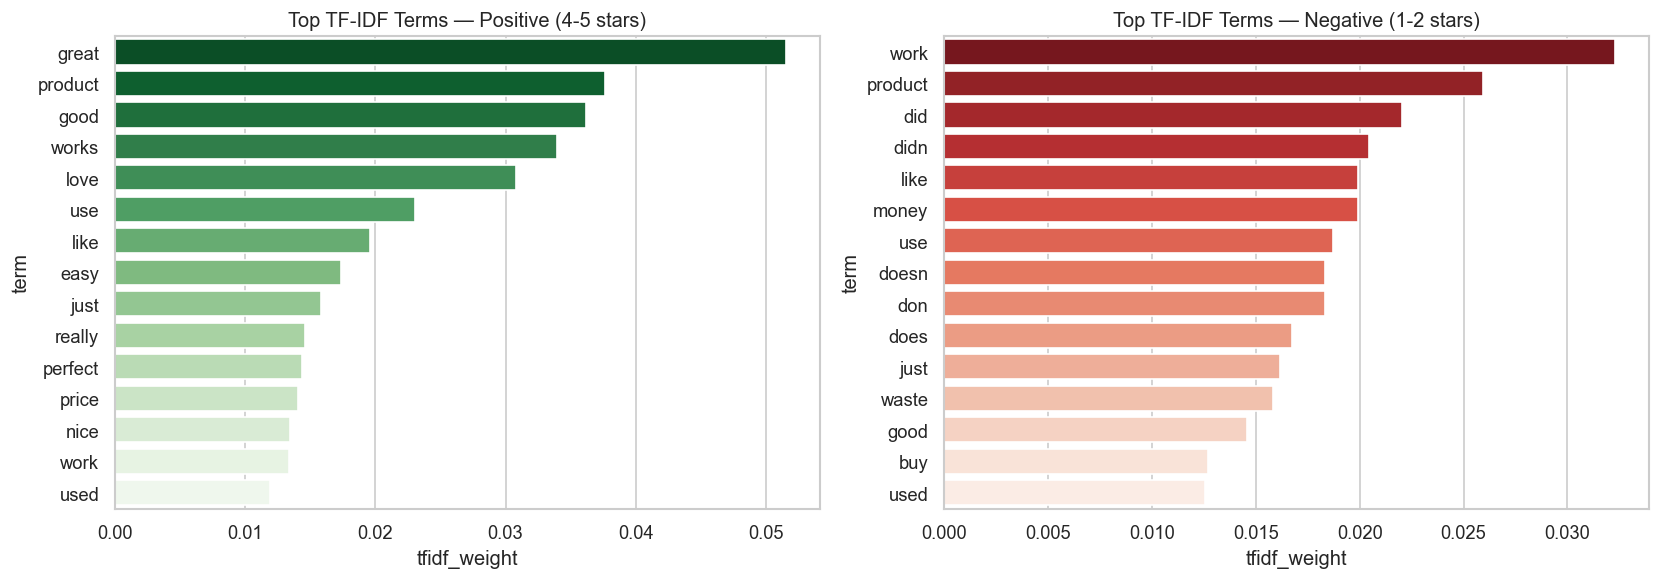

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Splitting into positive and negative groups (fillna to avoid vectorizer errors)
pos_texts = df[df["rating"] >= 4]["text"].fillna("").astype(str)
neg_texts = df[df["rating"] <= 2]["text"].fillna("").astype(str)

def top_tfidf_terms(texts, n=15):
    """Fit TF-IDF on a group of texts and return the top n terms by mean weight."""
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000, sublinear_tf=True)
    X = tfidf.fit_transform(texts)
    mean_weights = X.mean(axis=0).A1
    top_idx = mean_weights.argsort()[-n:][::-1]
    terms = tfidf.get_feature_names_out()[top_idx]
    weights = mean_weights[top_idx]
    return pd.DataFrame({"term": terms, "tfidf_weight": weights})

top_pos = top_tfidf_terms(pos_texts)
top_neg = top_tfidf_terms(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x="tfidf_weight", y="term", data=top_pos, ax=axes[0], palette="Greens_r")
axes[0].set_title("Top TF-IDF Terms \u2014 Positive (4-5 stars)")

sns.barplot(x="tfidf_weight", y="term", data=top_neg, ax=axes[1], palette="Reds_r")
axes[1].set_title("Top TF-IDF Terms \u2014 Negative (1-2 stars)")

plt.tight_layout()
plt.show()

## Sentiment Polarity Check

Quick polarity scoring with TextBlob to compare automated sentiment against the user-given star rating.

In [7]:
from textblob import TextBlob

# Computing polarity on a sample to keep it fast
POLARITY_SAMPLE = min(20_000, len(df))
df_pol = df.sample(POLARITY_SAMPLE, random_state=42).copy()
df_pol["polarity"] = df_pol["text"].fillna("").astype(str).apply(lambda t: TextBlob(t).sentiment.polarity)

# Average polarity per star rating
pol_by_rating = df_pol.groupby("rating")["polarity"].mean()
print("Average polarity by star rating:")
print(pol_by_rating)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x="rating", y="polarity", data=df_pol, ax=axes[0], palette="coolwarm")
axes[0].set_title("TextBlob Polarity by Rating")

# Mismatch analysis: low rating but high polarity (and vice versa)
df_pol["mismatch"] = (
    ((df_pol["rating"] <= 2) & (df_pol["polarity"] > 0.3)) |
    ((df_pol["rating"] >= 4) & (df_pol["polarity"] < -0.1))
)
mismatch_rate = df_pol["mismatch"].mean()
print(f"\nSentiment-rating mismatch rate: {mismatch_rate:.2%}")

sns.countplot(x="rating", hue="mismatch", data=df_pol, ax=axes[1], palette="Set2")
axes[1].set_title(f"Mismatches (rate: {mismatch_rate:.2%})")
axes[1].legend(title="Mismatch")

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'textblob'

## Quality & Duplicate Check

Final data quality pass: we look for duplicate reviews, empty texts and confirm no leakage exists in the cleaned dataset.

In [ ]:
# Checking for duplicate review texts
dup_text = df.duplicated(subset=["text"]).sum()
dup_user_product = df.duplicated(subset=["user_id", "parent_asin"]).sum()
empty_text = (df["text"].astype(str).str.strip().str.len() == 0).sum()

print(f"Duplicate review texts:          {dup_text:,}")
print(f"Duplicate user+product combos:   {dup_user_product:,}")
print(f"Empty text fields:               {empty_text:,}")

# Missing values in key columns after merge
key_cols = ["rating", "text", "parent_asin", "product_title", "brand", "price"]
missing_pct = df[key_cols].isna().mean().sort_values(ascending=False)
print("\nMissing % in key columns:")
print(missing_pct)

# Rating sanity check
print(f"\nRating range: {df['rating'].min()} \u2013 {df['rating'].max()}")
print(f"Rating value counts:\n{df['rating'].value_counts().sort_index()}")

Duplicate review texts:          25,523
Duplicate user+product combos:   4,040
Empty text fields:               0

Missing % in key columns:
price            0.571781
brand            0.296996
text             0.001548
product_title    0.000908
rating           0.000000
parent_asin      0.000000
dtype: float64

Rating range: 1 – 5
Rating value counts:
rating
1     43693
2     18698
3     23371
4     35496
5    197177
Name: count, dtype: int64
